<a href="https://colab.research.google.com/github/Salman9193/ml-finance-capstone/blob/main/corporate-finance-module/aurora_corporate_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aurora Corp — Corporate Finance Module: Project Funding Decisions
### Step 1 of the Aurora ML Finance System

**Objective:** Use Machine Learning to help Aurora decide *which internal projects to fund* — predicting NPV/cash flows, scoring project success probability, and ranking projects by risk-adjusted Expected Value.

**Deliverables:**
- Ranked project list with EV scores
- SHAP explainability plots for executives
- Recommendations summary

---

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (mean_absolute_error, r2_score,
                             classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression

import xgboost as xgb
import shap

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid", palette="muted")

print("All libraries loaded successfully")
print(f"XGBoost: {xgb.__version__}  |  SHAP: {shap.__version__}")

All libraries loaded successfully
XGBoost: 3.2.0  |  SHAP: 0.51.0


---
## 1. Data Loading & Exploratory Data Analysis (EDA)

In [3]:
df = pd.read_csv("corporate_projects.csv")
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (50, 10)


,Project_ID,Department,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Project_Risk,Success
0,1,Operations,184654,583556,2348816,1888756,0.08,0.05,Low,0
1,2,Marketing,2054354,1447527,541234,278576,0.15,-0.01,Low,1
2,3,Finance,2516182,1372905,1998260,2312990,0.19,0.02,High,1
3,4,Operations,3574675,1817640,189182,1434250,0.22,0.10,Medium,1
4,5,Operations,2752991,792139,1571101,111087,0.12,0.09,High,0
5,6,Marketing,2528388,482315,1256914,1063343,0.09,0.01,Low,0
6,7,Finance,628178,976075,234064,2132263,0.19,0.06,Medium,0
7,8,Finance,2763046,566588,264020,2265603,0.21,0.05,High,1
8,9,Operations,2686644,1335160,2022990,1546176,0.12,0.08,Medium,1
9,10,IT,2670406,1660908,947421,1936013,0.07,0.00,High,1


In [4]:
print("DATA TYPES & MISSING VALUES")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())

DATA TYPES & MISSING VALUES
Project_ID                   int64
Department                  object
Investment_Cost              int64
Expected_Cashflow_Year1      int64
Expected_Cashflow_Year2      int64
Expected_Cashflow_Year3      int64
Historical_ROI             float64
Market_Growth              float64
Project_Risk                object
Success                      int64
dtype: object

Missing values:
Project_ID                 0
Department                 0
Investment_Cost            0
Expected_Cashflow_Year1    0
Expected_Cashflow_Year2    0
Expected_Cashflow_Year3    0
Historical_ROI             0
Market_Growth              0
Project_Risk               0
Success                    0
dtype: int64


In [7]:
df.describe(include='all').round(2)

,Project_ID,Department,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Project_Risk,Success
count,50.00,50,50.00,50.00,50.00,50.00,50.00,50.00,50,50.00
unique,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,Marketing,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,16,NaN,NaN,NaN,NaN,NaN,NaN,20,NaN
mean,25.50,NaN,2508811.84,1019832.42,1245896.36,1513842.48,0.17,0.05,NaN,0.52
std,14.58,NaN,1250286.79,595306.45,755861.06,896571.17,0.06,0.05,NaN,0.50
min,1.00,NaN,123247.00,62666.00,71959.00,89353.00,0.05,-0.04,NaN,0.00
25%,13.25,NaN,1731652.25,532958.00,543187.00,816671.25,0.11,0.01,NaN,0.00
50%,25.50,NaN,2685837.50,1037419.50,1254198.00,1538295.50,0.16,0.05,NaN,1.00
75%,37.75,NaN,3480670.75,1475176.25,1993303.50,2263428.00,0.22,0.09,NaN,1.00


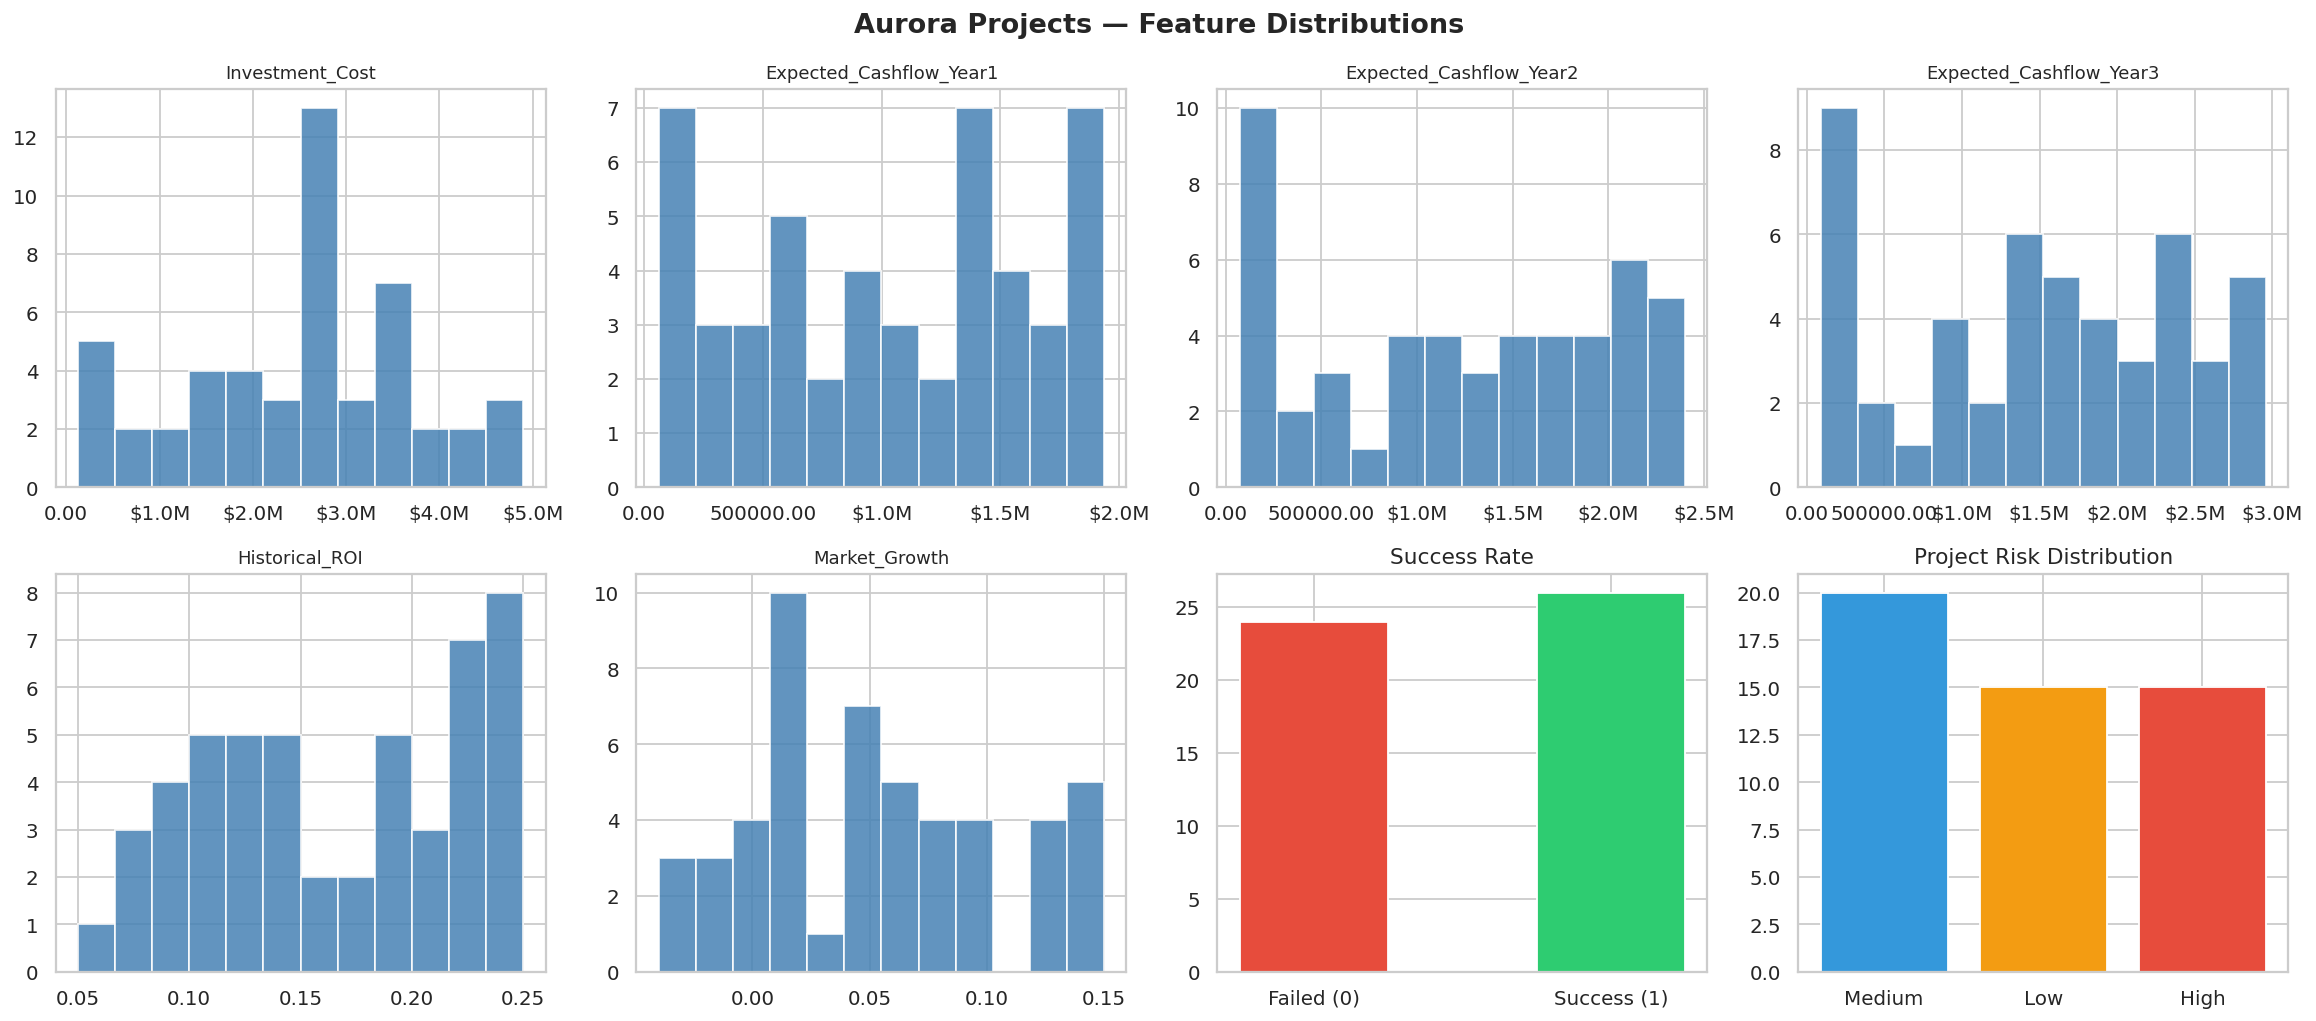

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Aurora Projects — Feature Distributions", fontsize=15, fontweight="bold")

numeric_cols = ["Investment_Cost", "Expected_Cashflow_Year1",
                "Expected_Cashflow_Year2", "Expected_Cashflow_Year3",
                "Historical_ROI", "Market_Growth"]

for i, col in enumerate(numeric_cols):
    ax = axes[i // 4][i % 4]
    ax.hist(df[col], bins=12, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.xaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if abs(x) >= 1e6 else f"{x:.2f}"))

axes[1][2].bar(["Failed (0)", "Success (1)"],
               df["Success"].value_counts().sort_index().values,
               color=["#e74c3c", "#2ecc71"], width=0.5)
axes[1][2].set_title("Success Rate")

risk_counts = df["Project_Risk"].value_counts()
axes[1][3].bar(risk_counts.index, risk_counts.values,
               color=["#3498db", "#f39c12", "#e74c3c"])
axes[1][3].set_title("Project Risk Distribution")

plt.tight_layout()
plt.savefig("01_feature_distributions.png", bbox_inches="tight")
plt.show()

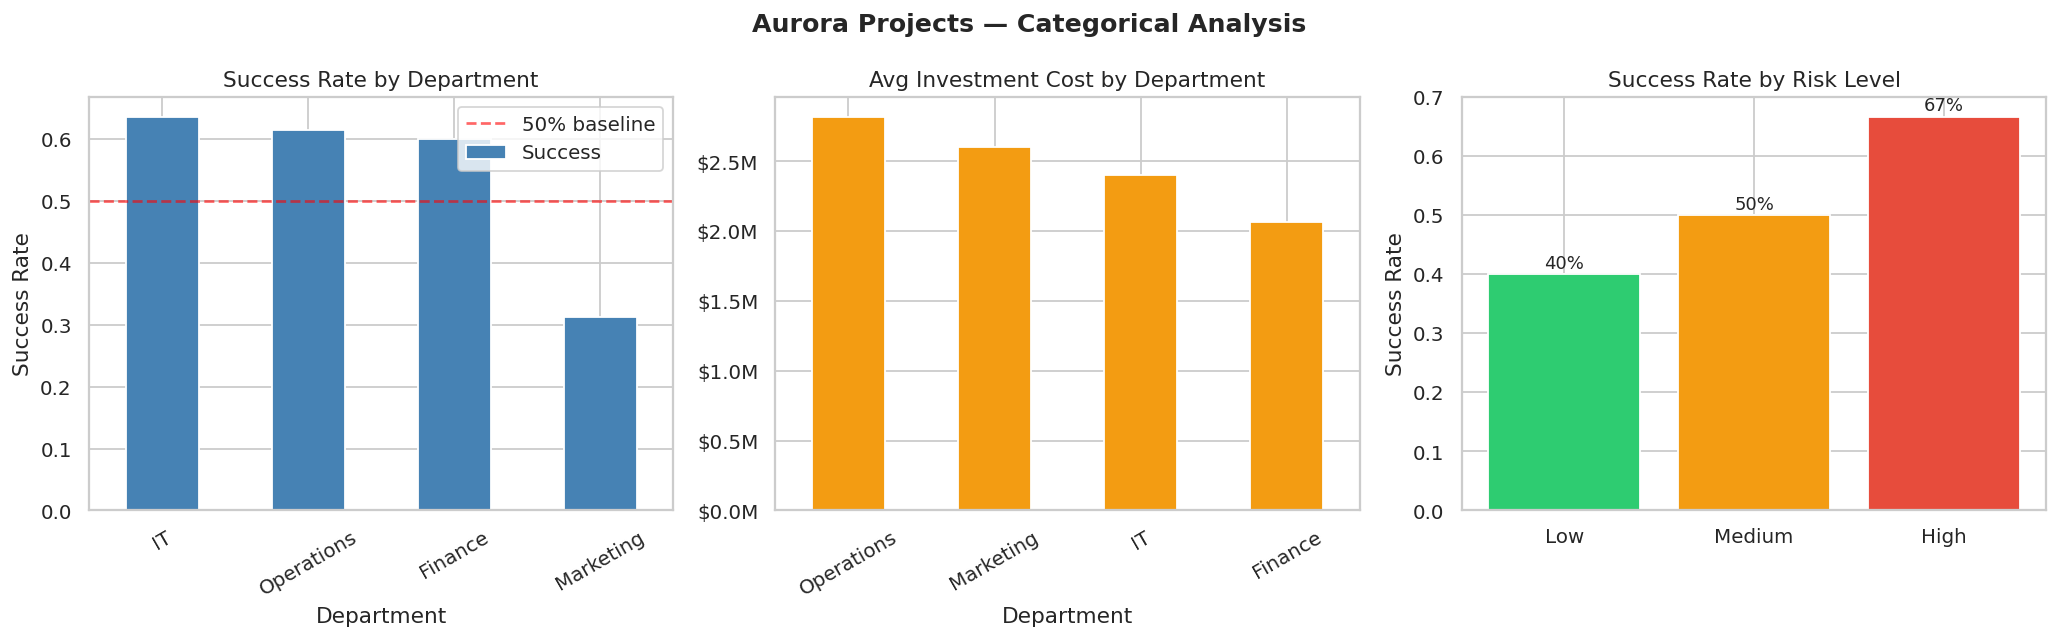

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Aurora Projects — Categorical Analysis", fontsize=14, fontweight="bold")

dept_success = df.groupby("Department")["Success"].mean().sort_values(ascending=False)
dept_success.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Success Rate by Department")
axes[0].set_ylabel("Success Rate")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].axhline(0.5, color="red", linestyle="--", alpha=0.6, label="50% baseline")
axes[0].legend()

dept_inv = df.groupby("Department")["Investment_Cost"].mean().sort_values(ascending=False)
dept_inv.plot(kind="bar", ax=axes[1], color="#f39c12", edgecolor="white")
axes[1].set_title("Avg Investment Cost by Department")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

risk_order = ["Low", "Medium", "High"]
risk_success = df.groupby("Project_Risk")["Success"].mean().reindex(risk_order)
bars = axes[2].bar(risk_success.index, risk_success.values,
                   color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="white")
axes[2].set_title("Success Rate by Risk Level")
axes[2].set_ylabel("Success Rate")
for bar, val in zip(bars, risk_success.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.0%}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("02_categorical_analysis.png", bbox_inches="tight")
plt.show()

---
## 2. Feature Engineering

We derive financially meaningful features:
- **NPV** (Net Present Value at 10% WACC discount rate)
- **Total Cash Flow** (undiscounted 3-year sum)
- **Profit** = Total_Cashflow − Investment_Cost
- **ROI_Proj** = Profit / Investment_Cost
- **Risk_Score** numeric: Low=1, Medium=2, High=3
- **EV** (Expected Value = P(Success) × NPV — computed after modelling)

In [11]:
WACC = 0.10  # Weighted Average Cost of Capital

df["NPV"] = (
    -df["Investment_Cost"]
    + df["Expected_Cashflow_Year1"] / (1 + WACC)**1
    + df["Expected_Cashflow_Year2"] / (1 + WACC)**2
    + df["Expected_Cashflow_Year3"] / (1 + WACC)**3
).round(2)

df["Total_Cashflow"] = (df["Expected_Cashflow_Year1"]
                        + df["Expected_Cashflow_Year2"]
                        + df["Expected_Cashflow_Year3"])

df["Profit"]   = df["Total_Cashflow"] - df["Investment_Cost"]
df["ROI_Proj"] = (df["Profit"] / df["Investment_Cost"]).round(4)

risk_map = {"Low": 1, "Medium": 2, "High": 3}
df["Risk_Score"]   = df["Project_Risk"].map(risk_map)

dept_encoder = LabelEncoder()
df["Dept_Encoded"] = dept_encoder.fit_transform(df["Department"])

print("Feature engineering complete")
print(f"NPV range: ${df['NPV'].min():,.0f}  to  ${df['NPV'].max():,.0f}")
print()
df[["Project_ID","Department","NPV","Investment_Cost","Project_Risk"]].nlargest(5,"NPV")

Feature engineering complete
NPV range: $-3,809,639  to  $4,281,887



,Project_ID,Department,NPV,Investment_Cost,Project_Risk
48,49,IT,4281886.77,123247,High
0,1,Operations,3706072.04,184654,Low
34,35,IT,3690875.91,296769,Medium
42,43,IT,3653868.04,664685,Medium
15,16,Finance,3290089.81,168148,Low


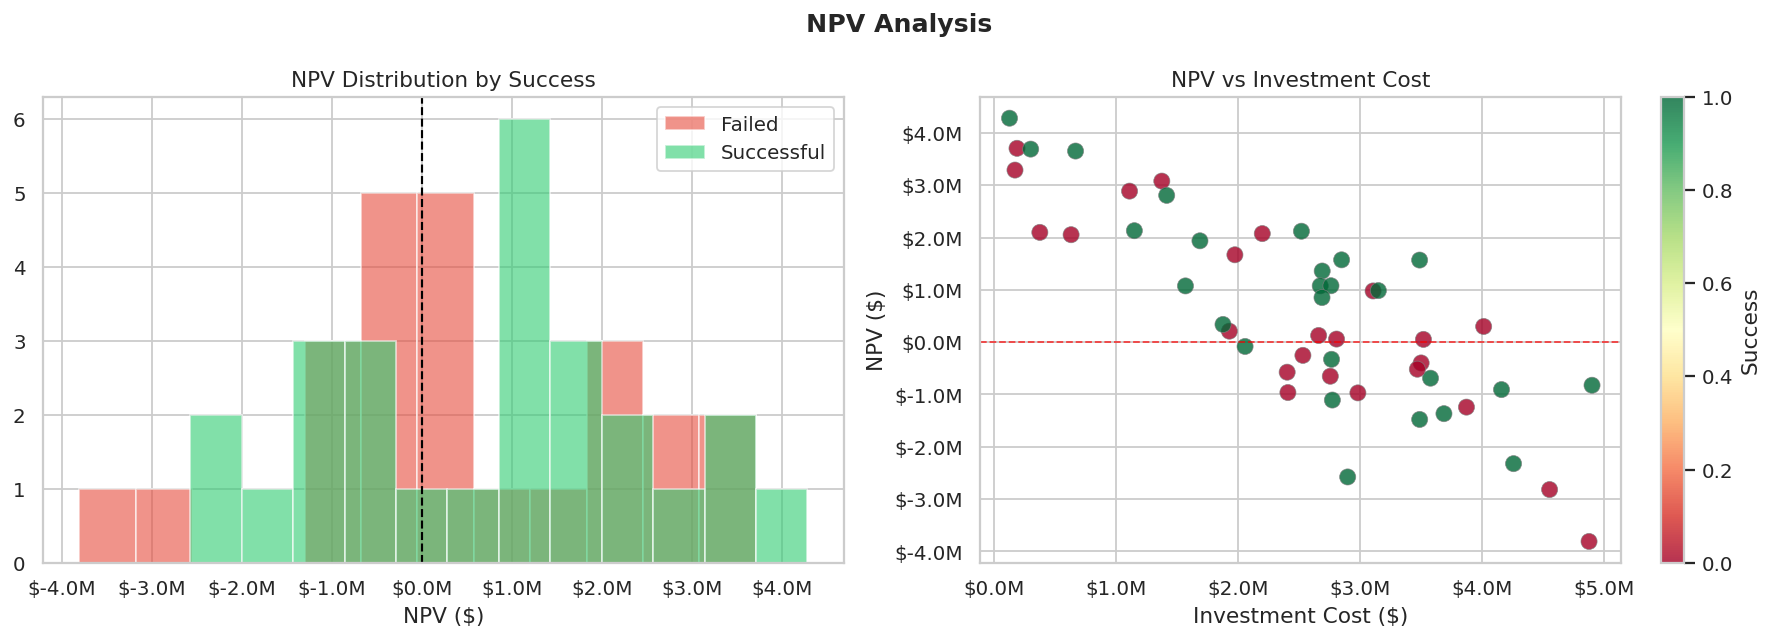

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("NPV Analysis", fontsize=14, fontweight="bold")

for label, grp in df.groupby("Success"):
    axes[0].hist(grp["NPV"], bins=12, alpha=0.6,
                 label=["Failed","Successful"][label],
                 color=["#e74c3c","#2ecc71"][label], edgecolor="white")
axes[0].set_title("NPV Distribution by Success")
axes[0].set_xlabel("NPV ($)")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[0].legend()
axes[0].axvline(0, color="black", linestyle="--", lw=1.2)

scatter = axes[1].scatter(df["Investment_Cost"], df["NPV"],
                          c=df["Success"], cmap="RdYlGn",
                          s=80, edgecolors="grey", linewidth=0.4, alpha=0.8)
axes[1].axhline(0, color="red", linestyle="--", lw=1, alpha=0.7)
axes[1].set_title("NPV vs Investment Cost")
axes[1].set_xlabel("Investment Cost ($)")
axes[1].set_ylabel("NPV ($)")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
fig.colorbar(scatter, ax=axes[1], label="Success")

plt.tight_layout()
plt.savefig("03_npv_analysis.png", bbox_inches="tight")
plt.show()

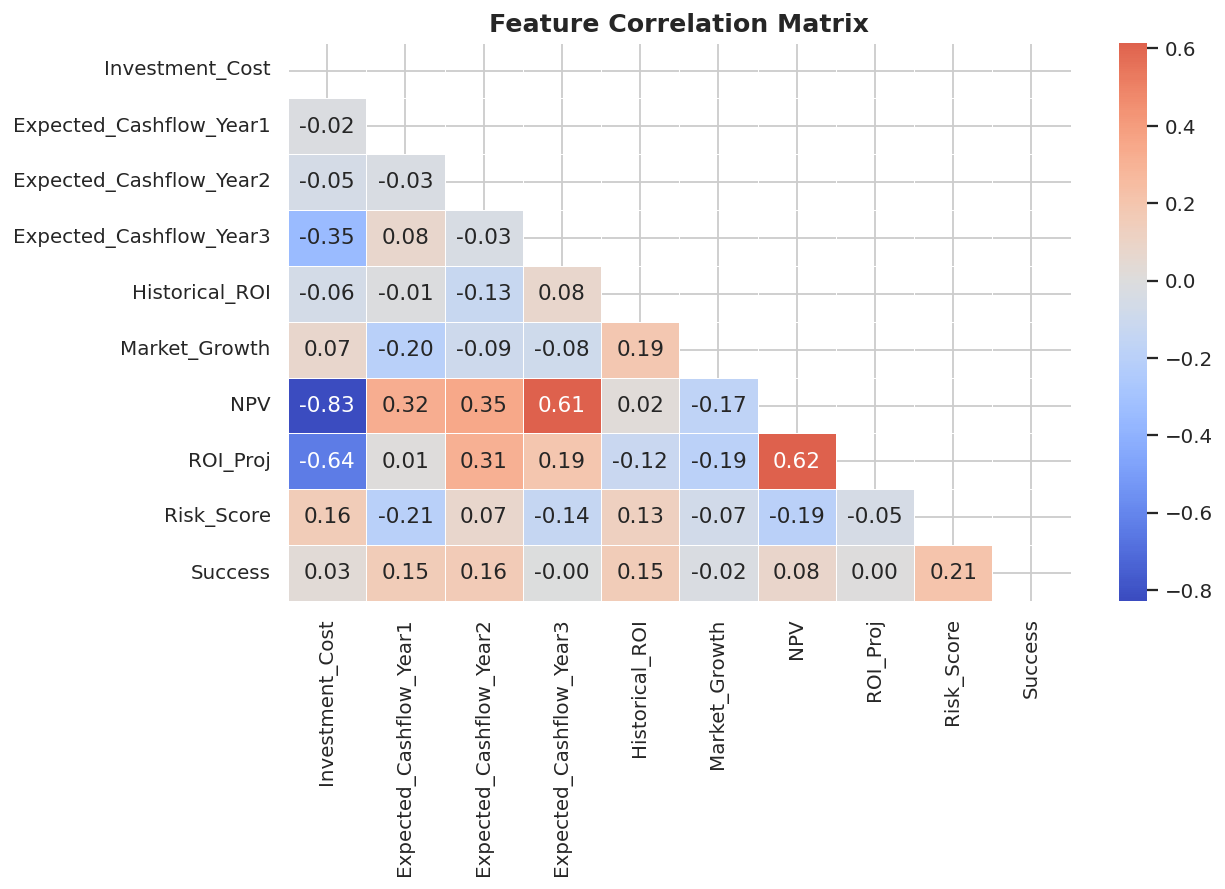

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
numeric_df = df[["Investment_Cost","Expected_Cashflow_Year1","Expected_Cashflow_Year2",
                  "Expected_Cashflow_Year3","Historical_ROI","Market_Growth",
                  "NPV","ROI_Proj","Risk_Score","Success"]]
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

---
## 3. Task A — Regression: Predicting NPV & Cash Flows

We train an **XGBoost Regressor** and a **Random Forest Regressor** to predict NPV.  
This lets Aurora estimate financial return for *new or hypothetical* projects before committing capital.

In [14]:
REG_FEATURES = ["Investment_Cost","Expected_Cashflow_Year1","Expected_Cashflow_Year2",
                 "Expected_Cashflow_Year3","Historical_ROI","Market_Growth",
                 "Risk_Score","Dept_Encoded"]

X_reg = df[REG_FEATURES]
y_reg = df["NPV"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train_r)}  |  Test samples: {len(X_test_r)}")
print(f"Target NPV range: ${y_reg.min():,.0f}  to  ${y_reg.max():,.0f}")

Training samples: 40  |  Test samples: 10
Target NPV range: $-3,809,639  to  $4,281,887


In [15]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)

rf_reg  = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
lr_reg  = LinearRegression()

models_reg = {"XGBoost": xgb_reg, "Random Forest": rf_reg, "Linear Regression": lr_reg}
reg_results = {}

for name, model in models_reg.items():
    model.fit(X_train_r, y_train_r)
    preds  = model.predict(X_test_r)
    mae    = mean_absolute_error(y_test_r, preds)
    r2     = r2_score(y_test_r, preds)
    cv_r2  = cross_val_score(model, X_reg, y_reg, cv=5, scoring="r2").mean()
    reg_results[name] = {"model": model, "preds": preds, "MAE": mae, "R2": r2, "CV_R2": cv_r2}
    print(f"{name:22s} | MAE: ${mae:>12,.0f} | R²: {r2:.4f} | 5-Fold CV R²: {cv_r2:.4f}")

XGBoost                | MAE: $     718,420 | R²: 0.8112 | 5-Fold CV R²: 0.8263
Random Forest          | MAE: $     859,087 | R²: 0.7693 | 5-Fold CV R²: 0.7631
Linear Regression      | MAE: $           0 | R²: 1.0000 | 5-Fold CV R²: 1.0000


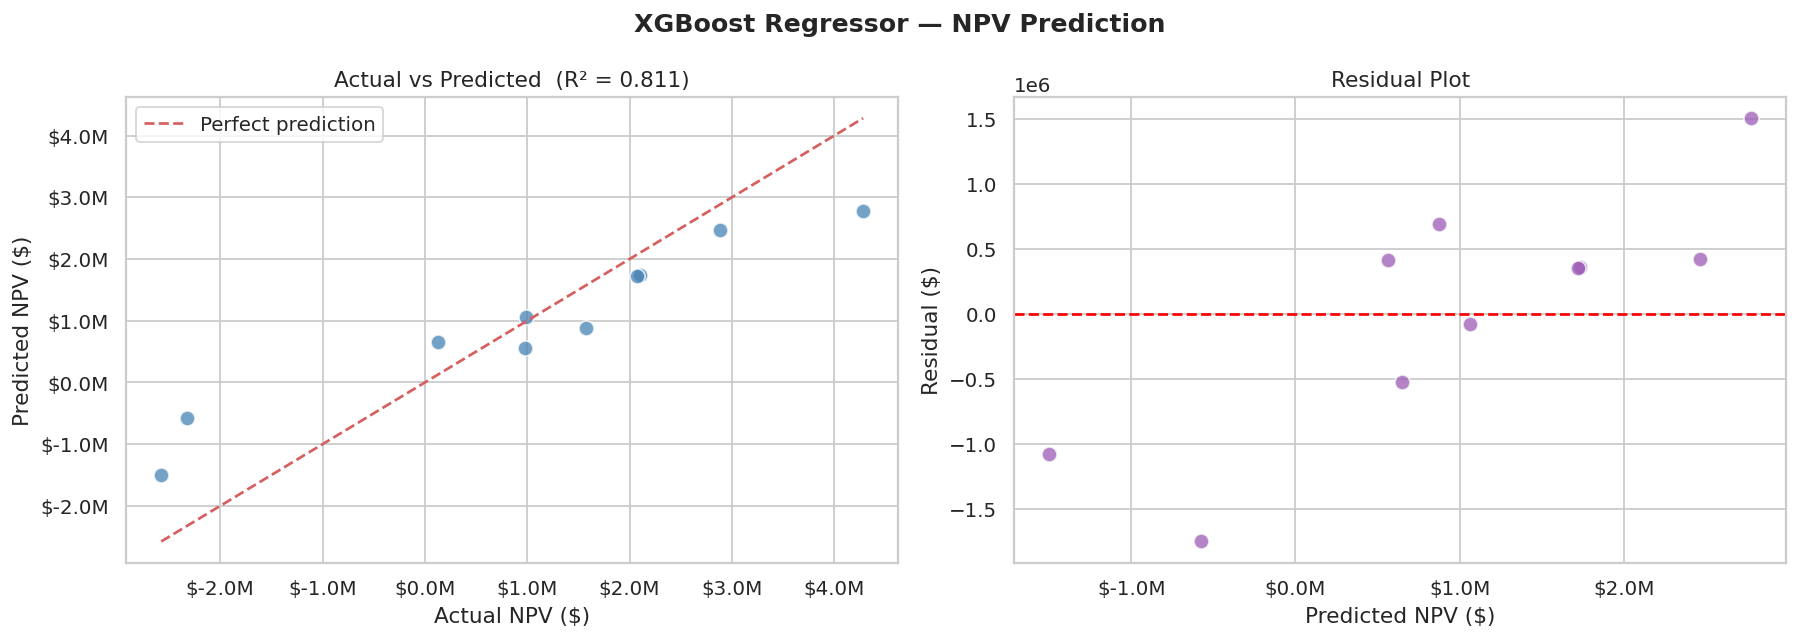

In [16]:
y_pred_r = reg_results["XGBoost"]["preds"]
r2_best  = reg_results["XGBoost"]["R2"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("XGBoost Regressor — NPV Prediction", fontsize=14, fontweight="bold")

axes[0].scatter(y_test_r, y_pred_r, alpha=0.75, color="steelblue", edgecolors="white", s=70)
lims = [min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual NPV ($)")
axes[0].set_ylabel("Predicted NPV ($)")
axes[0].set_title(f"Actual vs Predicted  (R² = {r2_best:.3f})")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[0].legend()

residuals = y_test_r.values - y_pred_r
axes[1].scatter(y_pred_r, residuals, alpha=0.75, color="#9b59b6", edgecolors="white", s=70)
axes[1].axhline(0, color="red", linestyle="--", lw=1.5)
axes[1].set_xlabel("Predicted NPV ($)")
axes[1].set_ylabel("Residual ($)")
axes[1].set_title("Residual Plot")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig("05_regression_results.png", bbox_inches="tight")
plt.show()

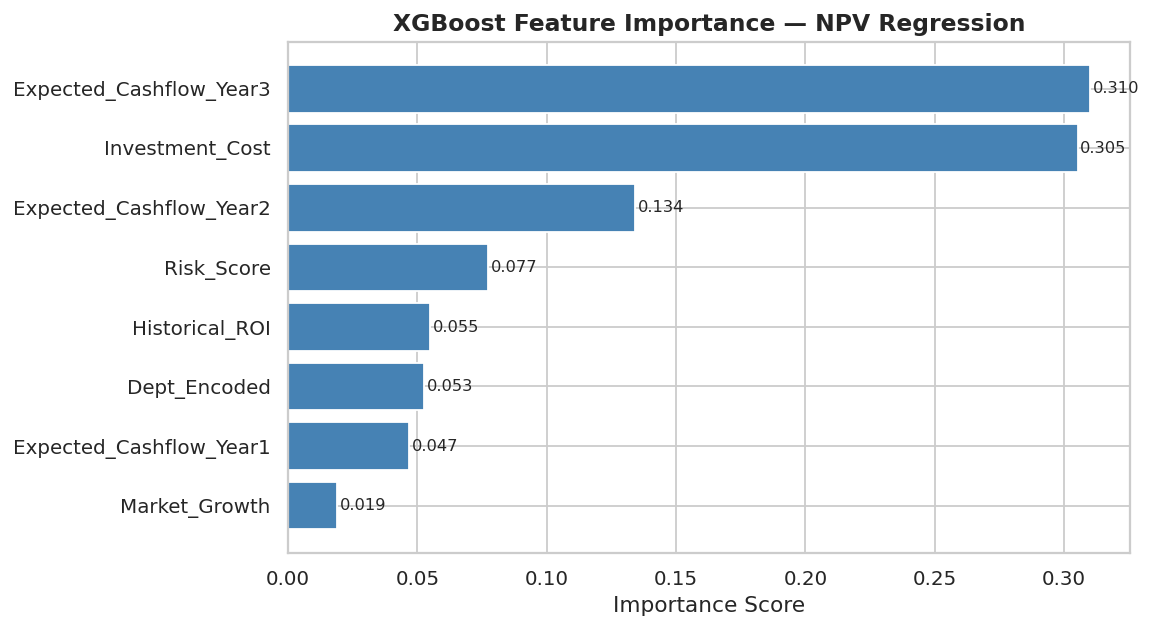

In [17]:
feat_imp = pd.Series(xgb_reg.feature_importances_, index=REG_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_imp.index, feat_imp.values, color="steelblue", edgecolor="white")
ax.set_title("XGBoost Feature Importance — NPV Regression", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
for bar, val in zip(bars, feat_imp.values):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("06_regression_feature_importance.png", bbox_inches="tight")
plt.show()

---
## 4. Task B — Classification: Predicting Project Success Probability

We train **XGBoost, Random Forest, and Logistic Regression** classifiers to predict whether a project will succeed.  
The predicted probability becomes the **success score** used in Expected Value ranking.

In [18]:
CLF_FEATURES = ["Investment_Cost","Expected_Cashflow_Year1","Expected_Cashflow_Year2",
                 "Expected_Cashflow_Year3","Historical_ROI","Market_Growth",
                 "Risk_Score","Dept_Encoded","NPV","ROI_Proj"]

X_clf = df[CLF_FEATURES]
y_clf = df["Success"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42)

print(f"Train: {len(X_train_c)} samples  |  Test: {len(X_test_c)} samples")
print(f"Overall success rate: {y_clf.mean():.1%}")

Train: 40 samples  |  Test: 10 samples
Overall success rate: 52.0%


In [19]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, verbosity=0)

rf_clf  = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
lr_clf  = LogisticRegression(max_iter=500, random_state=42)

models_clf = {"XGBoost": xgb_clf, "Random Forest": rf_clf, "Logistic Regression": lr_clf}
clf_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models_clf.items():
    model.fit(X_train_c, y_train_c)
    preds   = model.predict(X_test_c)
    probs   = model.predict_proba(X_test_c)[:, 1]
    auc     = roc_auc_score(y_test_c, probs)
    cv_auc  = cross_val_score(model, X_clf, y_clf, cv=skf, scoring="roc_auc").mean()
    clf_results[name] = {"model": model, "preds": preds, "probs": probs,
                          "AUC": auc, "CV_AUC": cv_auc}
    print(f"{name:22s} | Test AUC: {auc:.4f} | 5-Fold CV AUC: {cv_auc:.4f}")

XGBoost                | Test AUC: 0.4800 | 5-Fold CV AUC: 0.4430
Random Forest          | Test AUC: 0.4800 | 5-Fold CV AUC: 0.3777
Logistic Regression    | Test AUC: 0.4800 | 5-Fold CV AUC: 0.3720


XGBoost Classifier — Test Set Classification Report
              precision    recall  f1-score   support

      Failed       0.75      0.60      0.67         5
  Successful       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



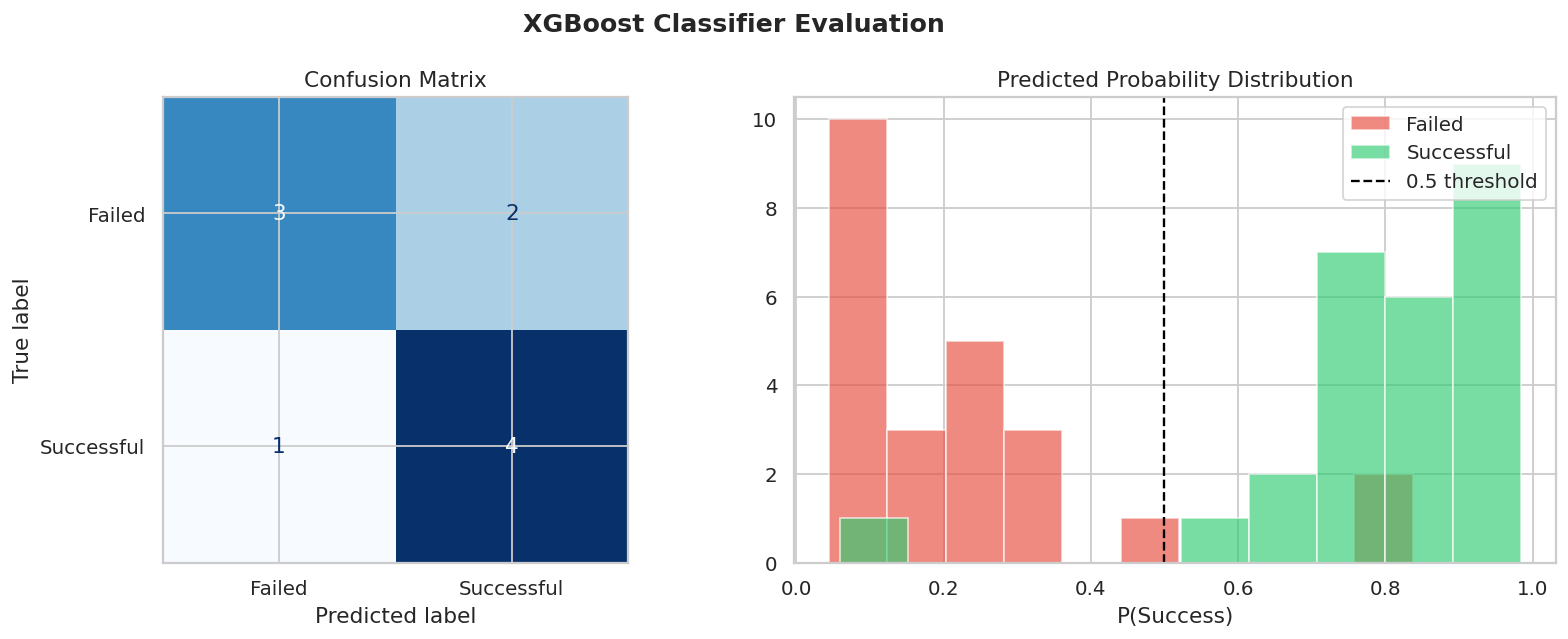

In [20]:
print("XGBoost Classifier — Test Set Classification Report")
print("=" * 50)
print(classification_report(y_test_c, clf_results["XGBoost"]["preds"],
                             target_names=["Failed","Successful"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("XGBoost Classifier Evaluation", fontsize=14, fontweight="bold")

cm = confusion_matrix(y_test_c, clf_results["XGBoost"]["preds"])
ConfusionMatrixDisplay(cm, display_labels=["Failed","Successful"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

for label, grp in df.assign(Prob=xgb_clf.predict_proba(X_clf)[:,1]).groupby("Success"):
    axes[1].hist(grp["Prob"], bins=10, alpha=0.65,
                 label=["Failed","Successful"][label],
                 color=["#e74c3c","#2ecc71"][label], edgecolor="white")
axes[1].axvline(0.5, color="black", linestyle="--", lw=1.3, label="0.5 threshold")
axes[1].set_title("Predicted Probability Distribution")
axes[1].set_xlabel("P(Success)")
axes[1].legend()

plt.tight_layout()
plt.savefig("07_classification_results.png", bbox_inches="tight")
plt.show()

---
## 5. SHAP Explainability — Executive Interpretation

SHAP (SHapley Additive exPlanations) reveals *why* each project gets a given success score.  
These plots replace the black-box with interpretable, executive-ready explanations.

In [21]:
explainer_clf = shap.TreeExplainer(xgb_clf)
shap_values_clf = explainer_clf.shap_values(X_clf)

shap_importance = pd.Series(
    np.abs(shap_values_clf).mean(axis=0), index=CLF_FEATURES
).sort_values(ascending=False)

print("Mean |SHAP| by feature (predicting Project Success):")
print(shap_importance.round(4).to_string())

Mean |SHAP| by feature (predicting Project Success):
Expected_Cashflow_Year1    1.0043
Historical_ROI             0.4676
Expected_Cashflow_Year3    0.4208
Investment_Cost            0.3584
NPV                        0.2660
ROI_Proj                   0.1947
Market_Growth              0.1840
Expected_Cashflow_Year2    0.1835
Dept_Encoded               0.1650
Risk_Score                 0.1293


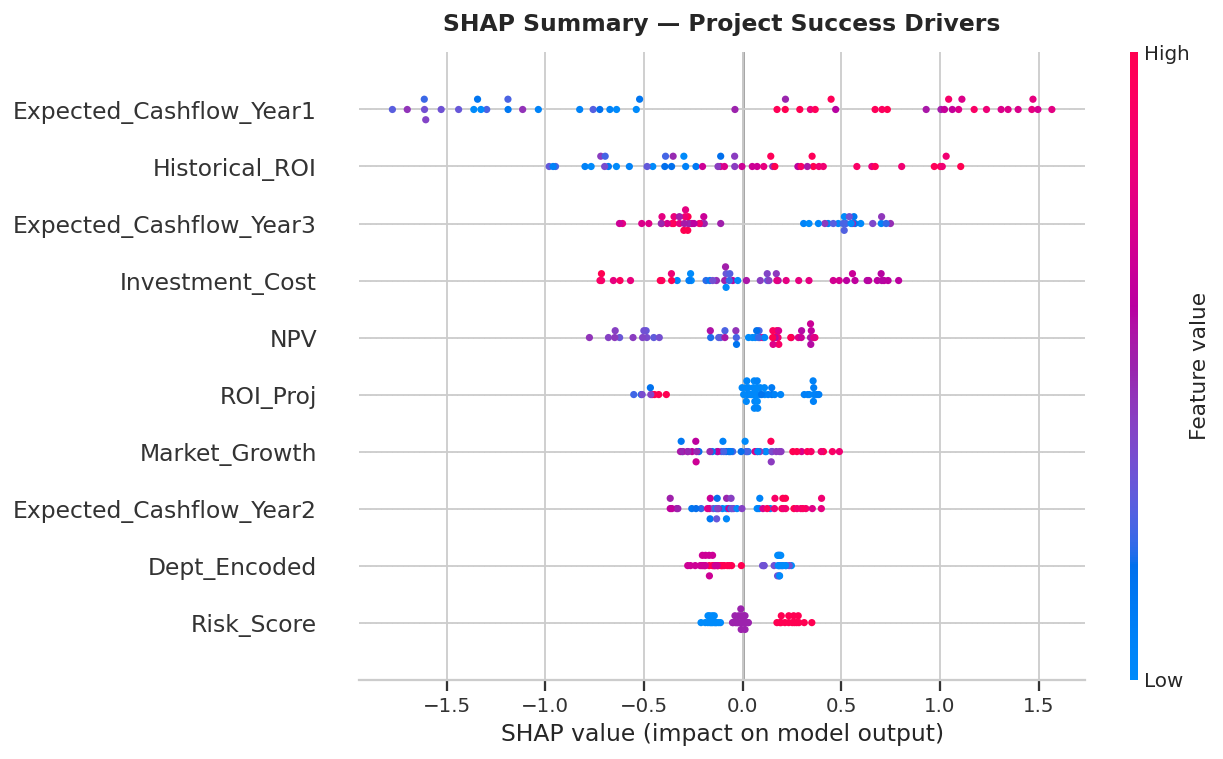

In [22]:
# SHAP Beeswarm Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_clf, X_clf, feature_names=CLF_FEATURES,
                  show=False, plot_size=(10, 6))
plt.title("SHAP Summary — Project Success Drivers", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("08_shap_summary_beeswarm.png", bbox_inches="tight", dpi=130)
plt.show()

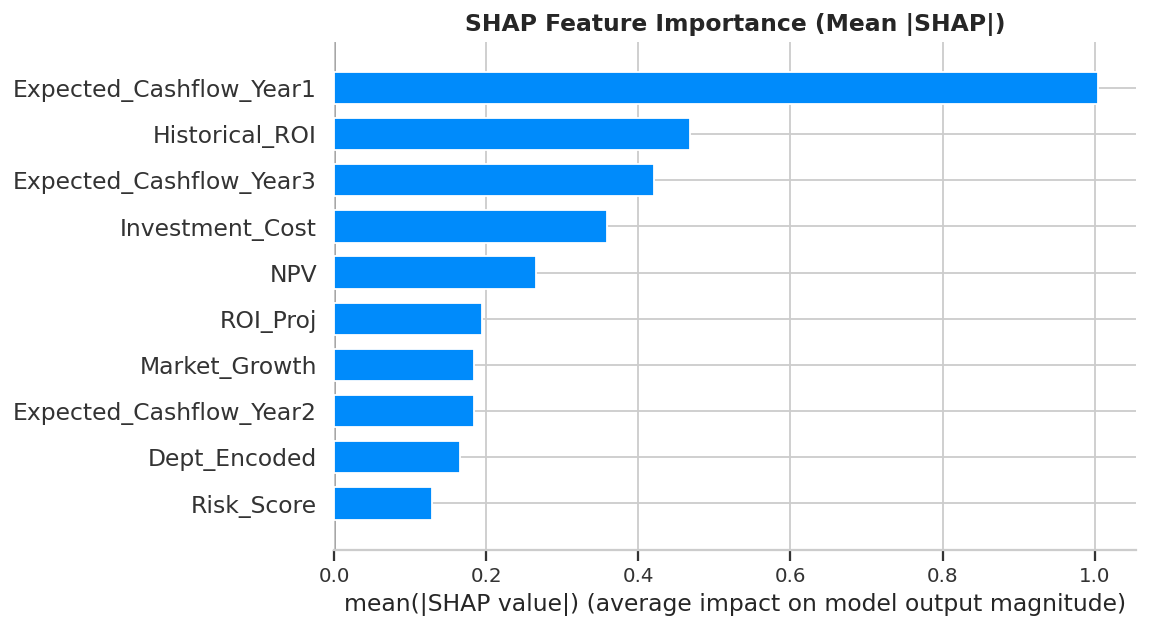

In [23]:
# SHAP Bar Plot
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values_clf, X_clf, feature_names=CLF_FEATURES,
                  plot_type="bar", show=False, plot_size=(9, 5))
plt.title("SHAP Feature Importance (Mean |SHAP|)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("09_shap_bar_importance.png", bbox_inches="tight", dpi=130)
plt.show()

Explaining Project #36
Department: Finance
Predicted P(Success): 98.4%


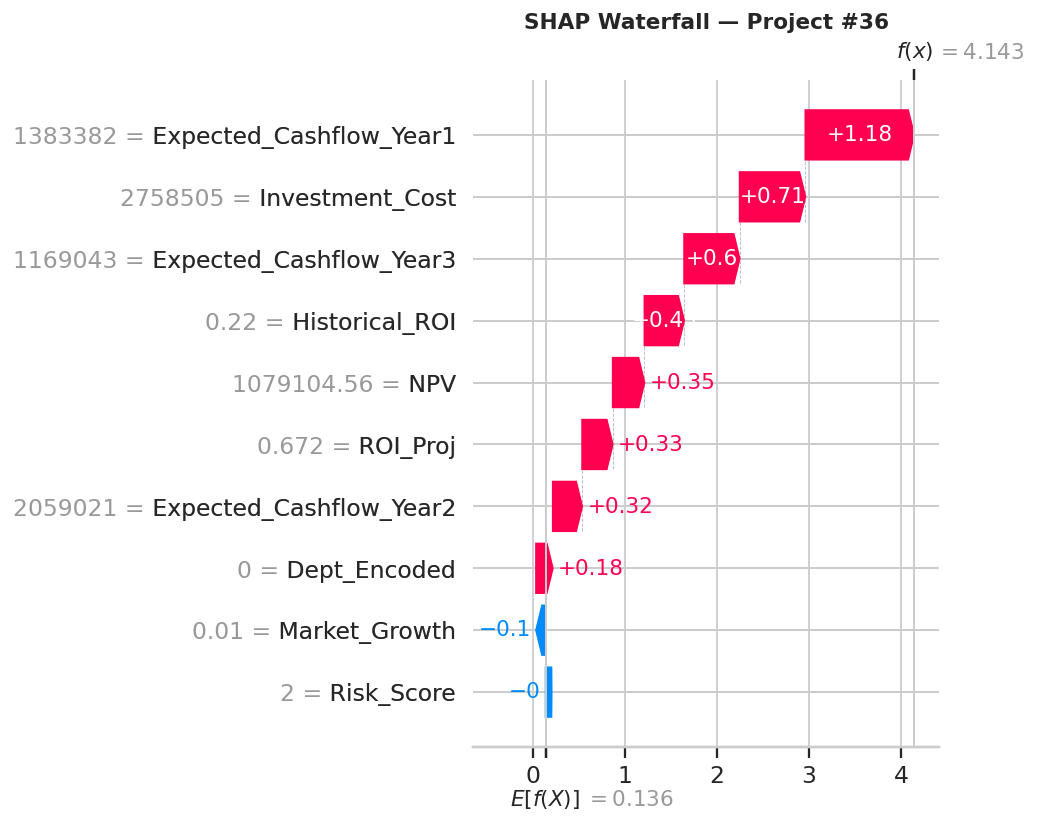

In [24]:
# SHAP Waterfall — top individual project explanation
best_proj_idx = xgb_clf.predict_proba(X_clf)[:,1].argmax()
print(f"Explaining Project #{df.iloc[best_proj_idx]['Project_ID']}")
print(f"Department: {df.iloc[best_proj_idx]['Department']}")
print(f"Predicted P(Success): {xgb_clf.predict_proba(X_clf)[best_proj_idx, 1]:.1%}")

explainer2 = shap.Explainer(xgb_clf, X_clf)
shap_exp   = explainer2(X_clf)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp[best_proj_idx], max_display=10, show=False)
plt.title(f"SHAP Waterfall — Project #{df.iloc[best_proj_idx]['Project_ID']}",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("10_shap_waterfall_top_project.png", bbox_inches="tight", dpi=130)
plt.show()

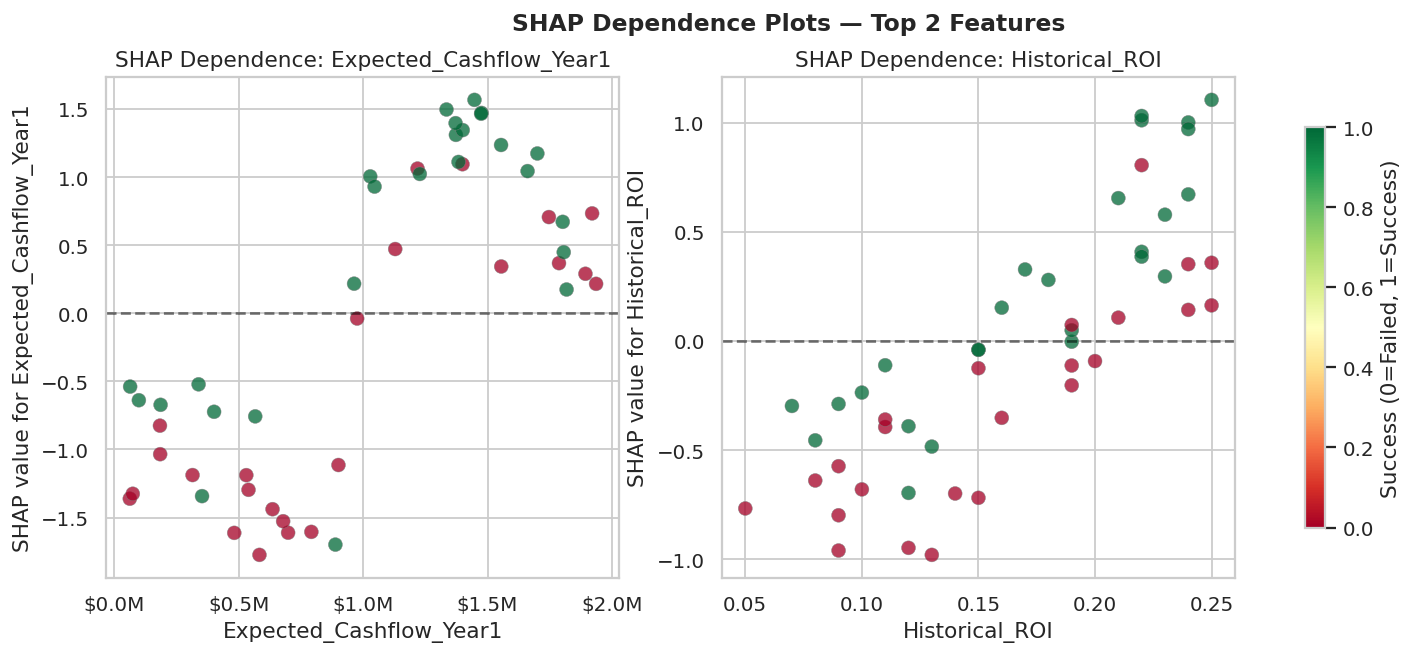

In [25]:
# SHAP Dependence Plots — top 2 features
top2 = shap_importance.index[:2].tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, feat in enumerate(top2):
    feat_idx = CLF_FEATURES.index(feat)
    axes[i].scatter(X_clf[feat].values, shap_values_clf[:, feat_idx],
                    c=df["Success"], cmap="RdYlGn", alpha=0.75,
                    s=60, edgecolors="grey", linewidth=0.3)
    axes[i].axhline(0, color="black", linestyle="--", alpha=0.5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(f"SHAP value for {feat}")
    axes[i].set_title(f"SHAP Dependence: {feat}")
    if any(k in feat for k in ["Cost","flow","NPV","Profit"]):
        axes[i].xaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(0,1))
fig.colorbar(sm, ax=axes, label="Success (0=Failed, 1=Success)", shrink=0.8)
fig.suptitle("SHAP Dependence Plots — Top 2 Features", fontsize=13, fontweight="bold")
plt.savefig("11_shap_dependence.png", bbox_inches="tight", dpi=130)
plt.show()

---
## 6. Task C — Project Ranking: Expected Value & Risk-Adjusted Return

**Expected Value (EV)**:
$$EV = P(\text{Success}) \times NPV_{\text{predicted}}$$

**Risk-Adjusted EV**:
$$\text{Risk-Adj EV} = \frac{EV}{\text{Risk Score}}  \quad (\text{Low}=1,\ \text{Medium}=2,\ \text{High}=3)$$

**Composite Score** = normalised blend of EV, Risk-Adj EV, Profitability Index, Historical ROI, and Market Growth.

In [26]:
df["Predicted_NPV"]       = xgb_reg.predict(df[REG_FEATURES]).round(2)
df["Success_Probability"] = xgb_clf.predict_proba(df[CLF_FEATURES])[:, 1].round(4)
df["EV"]                  = (df["Success_Probability"] * df["Predicted_NPV"]).round(2)
df["Risk_Adjusted_EV"]    = (df["EV"] / df["Risk_Score"]).round(2)
df["Profitability_Index"] = (df["Total_Cashflow"] / df["Investment_Cost"]).round(4)

scaler = MinMaxScaler()
score_cols = ["EV","Risk_Adjusted_EV","Profitability_Index","Historical_ROI","Market_Growth"]
df["Composite_Score"] = scaler.fit_transform(df[score_cols]).mean(axis=1).round(4)

print("Ranking metrics computed")
df[["Project_ID","Department","Investment_Cost","NPV","Success_Probability",
    "EV","Risk_Adjusted_EV","Composite_Score","Project_Risk"]].sort_values(
    "Composite_Score", ascending=False).head(10)

Ranking metrics computed


,Project_ID,Department,Investment_Cost,NPV,Success_Probability,EV,Risk_Adjusted_EV,Composite_Score,Project_Risk
42,43,IT,664685,3653868.04,0.7041,2.568620e+06,1284310.25,0.7340,Medium
24,25,Marketing,1970928,1670666.10,0.8049,1.327870e+06,663934.88,0.6370,Medium
34,35,IT,296769,3690875.91,0.8565,3.146789e+06,1573394.38,0.6235,Medium
48,49,IT,123247,4281886.77,0.7751,2.150798e+06,716932.75,0.5596,High
38,39,Finance,1146797,2131233.11,0.7989,1.692229e+06,1692228.75,0.5439,Low
41,42,Operations,2685031,853386.05,0.8109,6.873548e+05,229118.27,0.5394,High
27,28,IT,1873415,338974.17,0.9602,3.278371e+05,163918.55,0.5191,Medium
15,16,Finance,168148,3290089.81,0.1300,4.285088e+05,428508.84,0.5038,Low
12,13,Operations,3485357,1569700.27,0.9176,1.439020e+06,1439019.62,0.4796,Low
2,3,Finance,2516182,2121151.62,0.9471,1.987786e+06,662595.17,0.4695,High


In [27]:
ranked = df.copy()
ranked["Rank"] = ranked["Composite_Score"].rank(ascending=False).astype(int)
ranked = ranked.sort_values("Rank")

cutoff = ranked["Composite_Score"].quantile(0.60)
ranked["Recommendation"] = ranked.apply(
    lambda r: "FUND" if (r["Composite_Score"] >= cutoff and r["NPV"] > 0) else "HOLD", axis=1)

final_cols = ["Rank","Project_ID","Department","Project_Risk","Investment_Cost",
               "NPV","Success_Probability","EV","Risk_Adjusted_EV",
               "Composite_Score","Recommendation"]

print("=" * 85)
print("AURORA CORPORATE PROJECTS — RANKED FUNDING RECOMMENDATIONS")
print("=" * 85)
print(ranked[final_cols].to_string(index=False))

AURORA CORPORATE PROJECTS — RANKED FUNDING RECOMMENDATIONS
 Rank  Project_ID Department Project_Risk  Investment_Cost         NPV  Success_Probability            EV  Risk_Adjusted_EV  Composite_Score Recommendation
    1          43         IT       Medium           664685  3653868.04               0.7041  2.568620e+06        1284310.25           0.7340           FUND
    2          25  Marketing       Medium          1970928  1670666.10               0.8049  1.327870e+06         663934.88           0.6370           FUND
    3          35         IT       Medium           296769  3690875.91               0.8565  3.146789e+06        1573394.38           0.6235           FUND
    4          49         IT         High           123247  4281886.77               0.7751  2.150798e+06         716932.75           0.5596           FUND
    5          39    Finance          Low          1146797  2131233.11               0.7989  1.692229e+06        1692228.75           0.5439           FUND
    6

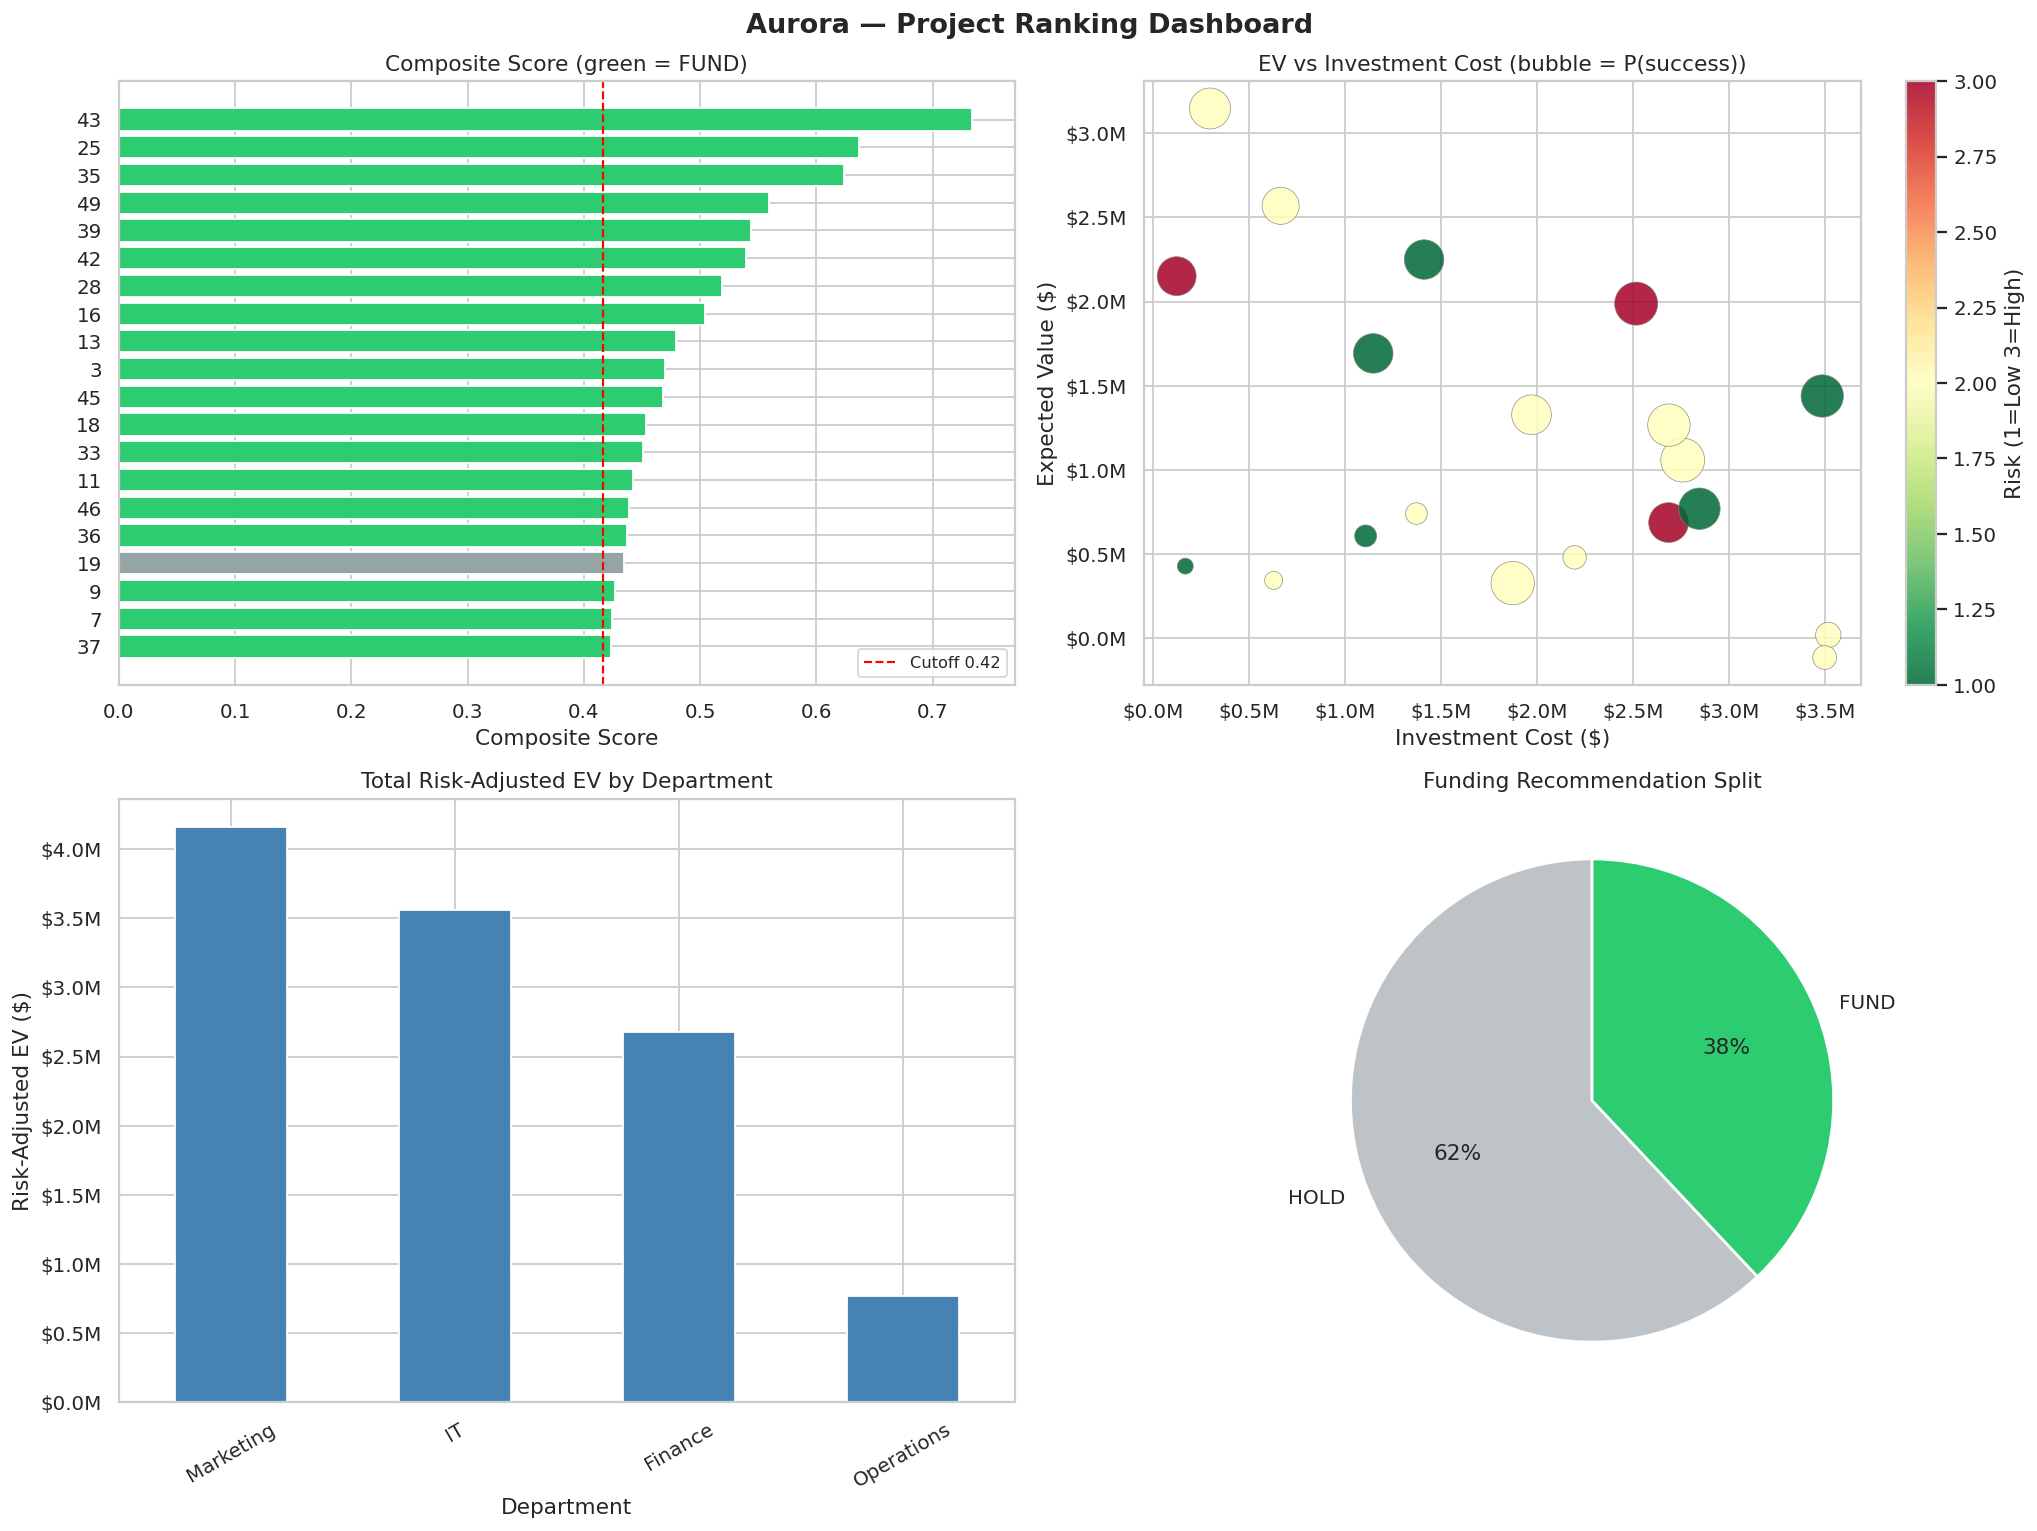

In [28]:
top20  = ranked.head(20).copy()
colors = ["#2ecc71" if r == "FUND" else "#95a5a6" for r in top20["Recommendation"]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Aurora — Project Ranking Dashboard", fontsize=15, fontweight="bold")

# Composite Score bar
axes[0,0].barh(top20["Project_ID"].astype(str), top20["Composite_Score"],
               color=colors, edgecolor="white")
axes[0,0].set_xlabel("Composite Score")
axes[0,0].set_title("Composite Score (green = FUND)")
axes[0,0].invert_yaxis()
axes[0,0].axvline(cutoff, color="red", linestyle="--", lw=1.2,
                   label=f"Cutoff {cutoff:.2f}")
axes[0,0].legend(fontsize=9)

# EV vs Investment bubble
sc = axes[0,1].scatter(top20["Investment_Cost"], top20["EV"],
                        s=top20["Success_Probability"]*600,
                        c=top20["Risk_Score"], cmap="RdYlGn_r",
                        edgecolors="grey", linewidth=0.4, alpha=0.85)
axes[0,1].set_xlabel("Investment Cost ($)")
axes[0,1].set_ylabel("Expected Value ($)")
axes[0,1].set_title("EV vs Investment Cost (bubble = P(success))")
axes[0,1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
fig.colorbar(sc, ax=axes[0,1], label="Risk (1=Low 3=High)")

# Risk-Adj EV by department
dept_ev = ranked.groupby("Department")["Risk_Adjusted_EV"].sum().sort_values(ascending=False)
dept_ev.plot(kind="bar", ax=axes[1,0], color="steelblue", edgecolor="white")
axes[1,0].set_title("Total Risk-Adjusted EV by Department")
axes[1,0].set_ylabel("Risk-Adjusted EV ($)")
axes[1,0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=30)

# Funding split pie
fund_counts = ranked["Recommendation"].value_counts()
pie_colors  = ["#2ecc71" if "FUND" in r else "#bdc3c7" for r in fund_counts.index]
axes[1,1].pie(fund_counts.values, labels=fund_counts.index,
               autopct="%1.0f%%", colors=pie_colors,
               startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1,1].set_title("Funding Recommendation Split")

plt.tight_layout()
plt.savefig("12_ranking_dashboard.png", bbox_inches="tight")
plt.show()

---
## 7. Executive Summary & Recommendations

In [29]:
fund = ranked[ranked["Recommendation"] == "FUND"]
hold = ranked[ranked["Recommendation"] == "HOLD"]

total_budget_fund = fund["Investment_Cost"].sum()
total_ev_fund     = fund["EV"].sum()
avg_prob_fund     = fund["Success_Probability"].mean()
avg_npv_fund      = fund["NPV"].mean()

print("=" * 65)
print("  AURORA CORPORATE FINANCE — EXECUTIVE SUMMARY")
print("=" * 65)
print(f"  Total projects evaluated       : {len(ranked)}")
print(f"  Projects recommended to FUND   : {len(fund)}")
print(f"  Projects on HOLD               : {len(hold)}")
print()
print(f"  Combined investment (FUND)     : ${total_budget_fund:>12,.0f}")
print(f"  Combined Expected Value (FUND) : ${total_ev_fund:>12,.0f}")
print(f"  EV / Investment ratio          :  {total_ev_fund/total_budget_fund:.2f}x")
print()
print(f"  Avg. Success Probability (FUND):  {avg_prob_fund:.1%}")
print(f"  Avg. Predicted NPV (FUND)      : ${avg_npv_fund:>12,.0f}")
print()
print("  TOP 5 PROJECTS TO FUND:")
print("-" * 65)
for _, row in fund.head(5).iterrows():
    print(f"  Rank {int(row.Rank):>2} | Project {int(row.Project_ID):>2} | "
          f"{row.Department:<12} | Risk: {row.Project_Risk:<7} | "
          f"Invest: ${row.Investment_Cost/1e6:.2f}M | "
          f"EV: ${row.EV/1e6:.2f}M | P(Success): {row.Success_Probability:.0%}")
print()
print("  KEY SHAP DRIVERS (top 3 features for success prediction):")
print("-" * 65)
for feat, val in shap_importance.head(3).items():
    print(f"  - {feat:<35}  Mean |SHAP| = {val:.4f}")
print()
print("  RECOMMENDATIONS:")
print("-" * 65)
print("  1. Fund the top-ranked projects — they show high NPV, strong")
print("     success probability, and favourable risk profiles.")
print("  2. High-risk projects with low P(success) should be staged or")
print("     restructured before full capital commitment.")
print("  3. Historical ROI and 3-year cash flow forecasts are the")
print("     strongest predictors — improve data quality there.")
print("  4. Re-run this model quarterly as market conditions evolve.")
print("=" * 65)

  AURORA CORPORATE FINANCE — EXECUTIVE SUMMARY
  Total projects evaluated       : 50
  Projects recommended to FUND   : 19
  Projects on HOLD               : 31

  Combined investment (FUND)     : $  33,452,508
  Combined Expected Value (FUND) : $  23,292,992
  EV / Investment ratio          :  0.70x

  Avg. Success Probability (FUND):  66.0%
  Avg. Predicted NPV (FUND)      : $   2,135,449

  TOP 5 PROJECTS TO FUND:
-----------------------------------------------------------------
  Rank  1 | Project 43 | IT           | Risk: Medium  | Invest: $0.66M | EV: $2.57M | P(Success): 70%
  Rank  2 | Project 25 | Marketing    | Risk: Medium  | Invest: $1.97M | EV: $1.33M | P(Success): 80%
  Rank  3 | Project 35 | IT           | Risk: Medium  | Invest: $0.30M | EV: $3.15M | P(Success): 86%
  Rank  4 | Project 49 | IT           | Risk: High    | Invest: $0.12M | EV: $2.15M | P(Success): 78%
  Rank  5 | Project 39 | Finance      | Risk: Low     | Invest: $1.15M | EV: $1.69M | P(Success): 80%

  

In [30]:
ranked[final_cols].to_csv("aurora_ranked_projects.csv", index=False)
print("Ranked project list saved to aurora_ranked_projects.csv")

Ranked project list saved to aurora_ranked_projects.csv
